In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import requests
from sklearn.model_selection import train_test_split
from openai import OpenAI
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


/Users/mahsaamani/Downloads/Saarlanduni/DataScience/UnveilingHospitalCostDrivers/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mahsaamani/Downloads/Saarlanduni/DataScience/UnveilingHospitalCostDrivers/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Load data
data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')
data.head()

/var/folders/s1/z7p70y8n35lcdk9lq0wvfxz00000gq/T/ipykernel_27469/1113152288.py:2: DtypeWarning: Columns (29) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('../data/Hospital_Inpatient_Discharges__SPARCS_De-Identified___2022_20250423.csv')


,Hospital Service Area,Hospital County,Operating Certificate Number,Permanent Facility Id,Facility Name,Age Group,Zip Code - 3 digits,Gender,Race,Ethnicity,...,APR Severity of Illness Description,APR Risk of Mortality,APR Medical Surgical Description,Payment Typology 1,Payment Typology 2,Payment Typology 3,Birth Weight,Emergency Department Indicator,Total Charges,Total Costs
0,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,50 to 69,107,F,White,Not Span/Hispanic,...,Major,Major,Medical,Medicaid,NaN,NaN,NaN,Y,"51,514.62","7,552.54"
1,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,M,Black/African American,Spanish/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"25,370.86","3,469.55"
2,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,104,F,Other Race,Spanish/Hispanic,...,Minor,Minor,Medical,Medicaid,NaN,NaN,NaN,N,"23,876.78","6,180.33"
3,New York City,Bronx,7000006.0,3058.0,Montefiore Med Center - Jack D Weiler Hosp of ...,18 to 29,100,F,Black/African American,Not Span/Hispanic,...,Moderate,Minor,Medical,Medicaid,NaN,NaN,NaN,Y,"43,319.05","12,588.93"
4,New York City,Bronx,7000006.0,1168.0,Montefiore Medical Center-Wakefield Hospital,18 to 29,104,M,Other Race,Spanish/Hispanic,...,Moderate,Moderate,Medical,Medicaid,NaN,NaN,NaN,Y,"40,266.23","10,355.99"


In [3]:
for col in data.columns:
    print(col, data[col].dtype)

Hospital Service Area object
Hospital County object
Operating Certificate Number float64
Permanent Facility Id float64
Facility Name object
Age Group object
Zip Code - 3 digits object
Gender object
Race object
Ethnicity object
Length of Stay object
Type of Admission object
Patient Disposition object
Discharge Year int64
CCSR Diagnosis Code object
CCSR Diagnosis Description object
CCSR Procedure Code object
CCSR Procedure Description object
APR DRG Code int64
APR DRG Description object
APR MDC Code int64
APR MDC Description object
APR Severity of Illness Code int64
APR Severity of Illness Description object
APR Risk of Mortality object
APR Medical Surgical Description object
Payment Typology 1 object
Payment Typology 2 object
Payment Typology 3 object
Birth Weight object
Emergency Department Indicator object
Total Charges object
Total Costs object


In [4]:
# Remove commas and convert to numeric
for col in ["Length of Stay", "Birth Weight", "Total Charges", "Total Costs"]:
    data[col] = pd.to_numeric(data[col].str.replace(',', '', regex=False), errors='coerce')


In [5]:
for col in data.columns:
    print(col, data[col].dtype)

Hospital Service Area object
Hospital County object
Operating Certificate Number float64
Permanent Facility Id float64
Facility Name object
Age Group object
Zip Code - 3 digits object
Gender object
Race object
Ethnicity object
Length of Stay float64
Type of Admission object
Patient Disposition object
Discharge Year int64
CCSR Diagnosis Code object
CCSR Diagnosis Description object
CCSR Procedure Code object
CCSR Procedure Description object
APR DRG Code int64
APR DRG Description object
APR MDC Code int64
APR MDC Description object
APR Severity of Illness Code int64
APR Severity of Illness Description object
APR Risk of Mortality object
APR Medical Surgical Description object
Payment Typology 1 object
Payment Typology 2 object
Payment Typology 3 object
Birth Weight float64
Emergency Department Indicator object
Total Charges float64
Total Costs float64


In [ ]:
# Handle missing numeric data
for col in data.columns:
    if data[col].dtype != "object":
        data[col] = data[col].fillna(data[col].median())

In [7]:
# Identify categorical columns 
categorical_columns = []
for col in data.columns:
    if data[col].dtype == "object":
        categorical_columns.append(col)

# Encode categorical columns
data_encoded = pd.get_dummies(data, columns=categorical_columns, drop_first=True)


In [8]:
# Preprocess data
X = data_encoded.drop(columns=['Total Costs'])
y = data_encoded['Total Costs']

In [9]:
prev_columns = X.columns
new_columns = []
for col in X.columns:
    if "[" in col or "]" in col:
        new_columns.append(col.replace('[', '').replace("]", ""))
    elif "<" in col:
        new_columns.append(col.replace("<", "less than"))
    else:
        new_columns.append(col)

In [10]:
X.columns = new_columns

In [11]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Train the model
model = xgb.XGBRegressor(objective='reg:squarederror', enable_categorical=True)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [ ]:
model.save_model("../model.json")

In [13]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 3894.10
MSE: 278250241.61
R²: 0.88


In [14]:
# Explain model predictions using SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

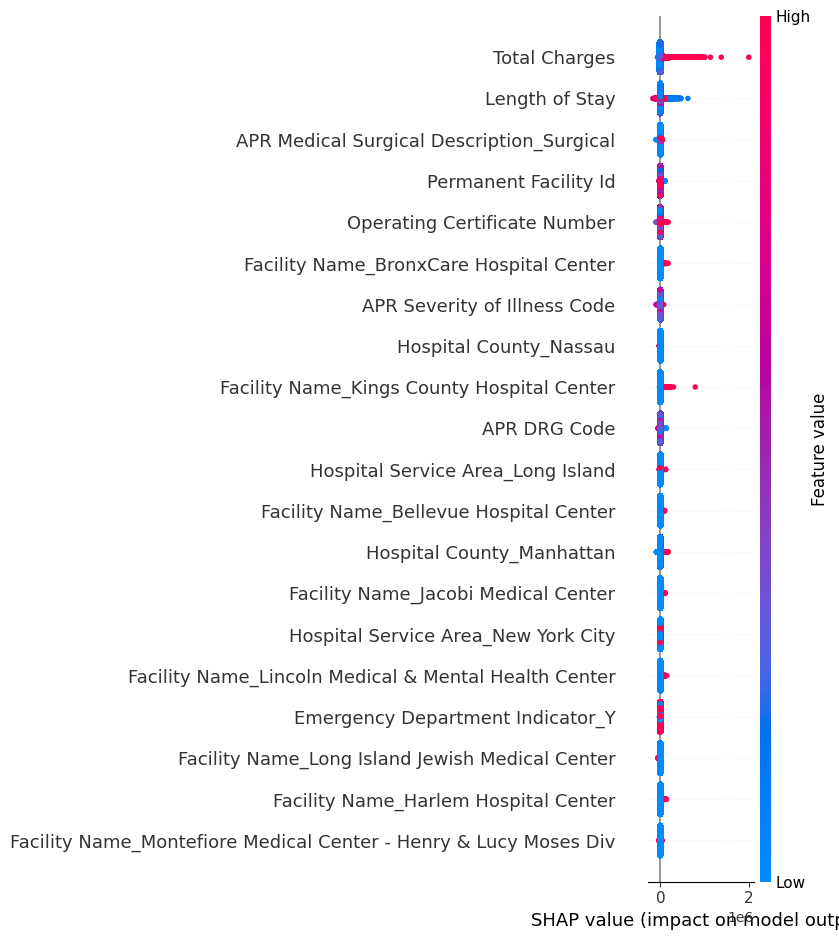

In [15]:
# Visualize feature importance
shap.summary_plot(shap_values, X_test)

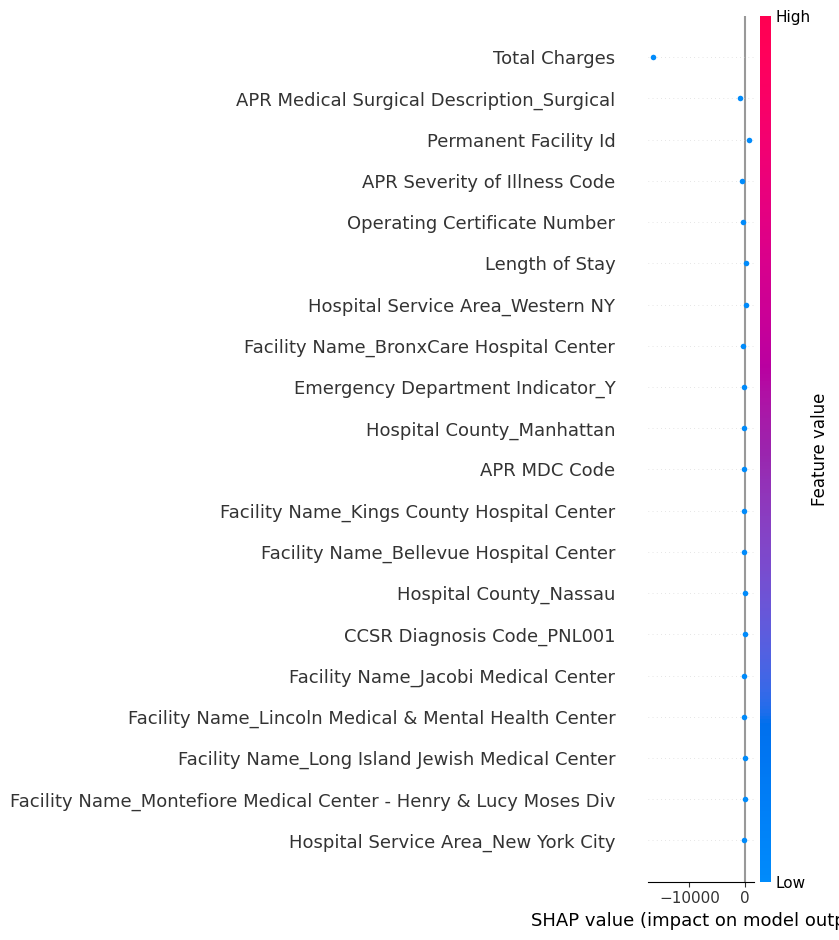

In [16]:
# checking the plot for 1 test sample
shap_values = explainer(X_test.iloc[0:1])
shap.summary_plot(shap_values, X_test.iloc[0:1])

In [17]:
def get_patient_shaply_values(test_patient_index):
    shap_values = explainer(X_test.iloc[test_patient_index:test_patient_index+1])

    # Calculate mean absolute SHAP values
    shap_mean = pd.DataFrame({
        'feature': X_test.columns,
        'mean_shap_value': shap_values.values.mean(axis=0)
    })

    # getting more effective features 
    # # 1. with removing least effective features
    # shap_mean_selected = shap_mean[(shap_mean['mean_shap_value'] > 10) | (shap_mean['mean_shap_value'] < -10)]
    # shap_mean_selected = shap_mean_selected.sort_values(by='mean_shap_value', ascending=False)

    # 2. selecting top most effective features
    shap_mean_selected = shap_mean.sort_values(by='mean_shap_value', ascending=False)
    shap_mean_selected = pd.concat([shap_mean_selected.head(5), shap_mean_selected.tail(5)])

    # print(shap_mean_selected)
    return shap_mean_selected

In [18]:
def patient_info(test_patient_index):
    patient_shap_mean_selected = get_patient_shaply_values(test_patient_index)
    info = dict()
    for i, row in patient_shap_mean_selected.iterrows():
        info[row["feature"]] = {"value": X_test.iloc[test_patient_index, X_test.columns.get_loc(row["feature"])].item(),
                                "shap value": row["mean_shap_value"]}
    return info

In [19]:
patient_info(0)

{'Permanent Facility Id': {'value': 207.0, 'shap value': 758.31201171875},
 'Length of Stay': {'value': 3.0, 'shap value': 325.9698486328125},
 'Hospital Service Area_Western NY': {'value': True,
  'shap value': 309.945068359375},
 'Hospital County_Nassau': {'value': False, 'shap value': 110.9489517211914},
 'CCSR Diagnosis Code_PNL001': {'value': False,
  'shap value': 90.85821533203125},
 'Facility Name_BronxCare Hospital Center': {'value': False,
  'shap value': -202.37481689453125},
 'Operating Certificate Number': {'value': 1401014.0,
  'shap value': -366.70660400390625},
 'APR Severity of Illness Code': {'value': 1, 'shap value': -383.013427734375},
 'APR Medical Surgical Description_Surgical': {'value': False,
  'shap value': -813.6758422851562},
 'Total Charges': {'value': 11499.47, 'shap value': -16616.2890625}}

In [20]:
SYSTEM_PROMPT = '''
You are an expert in healthcare cost optimization and hospital operations strategy.

Your task is to analyze structured data from inpatient hospital cases. For each input feature, you are given:
- Its actual value (e.g., age, length of stay, procedure type)
- Its SHAP value — a numerical measure of how much that feature contributed to the overall inpatient cost

You must identify the most impactful cost drivers and suggest actionable strategies to reduce their effect. For each strategy, recommend a practical method to implement it (e.g., policy change, workflow redesign, regional referral, or outpatient substitution).

Your responses should be:
- Strategic
- Specific
- Grounded in real-world hospital operations

Always aim to maintain or improve care quality while reducing costs.
'''

In [54]:
USER_PROMPT = f'''
Here is the structured data for a hospital inpatient case.

Each entry includes:
- "value": the observed data for the patient or hospital
- "shap value": the contribution of that feature to the overall inpatient cost (in dollars)

Please complete the following:

1. For each feature, propose a clear strategy which reduces the cost and is feasible to implement at the hospital or system level 
2. Conclude with a brief summary (2–3 sentences) explaining your overall reasoning.
3. Use this json format for your answer: {{"feature 1 name": "method", "feature 2 name": "method", ..., "Summary": "your summary"}}
4. Do not include any other text in your response. Just a json in the mentioned format.

Data: 
###patient_info###
'''

In [46]:

import streamlit.components.v1 as components

def plot_shap_force(shap_values):
    shap.initjs()
    force_plot = shap.plots.force(
        shap_values.base_values[0],
        shap_values.values[0],
        shap_values.data[0],
        matplotlib=False
    )
    components.html(force_plot.html(), height=300)

In [ ]:
def simulate_intervention(patient_data, changes, model, explainer):
    updated_data = patient_data.copy()
    updated_data.update(changes)
    new_cost = predict_cost(updated_data, model)
    new_shap = get_shap_values(updated_data, model, explainer)
    return new_cost, new_shap

In [62]:
from langchain_community.chat_models import ChatOpenAI
from langchain.schema import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI

# Choose a model available on OpenRouter (e.g., GPT-3.5, Mistral, Claude)
# llm = ChatOpenAI(
#     model="microsoft/phi-4-reasoning-plus:free",
#   # model="deepseek/deepseek-r1:free",
#     base_url="https://openrouter.ai/api/v1",
#     api_key="OR_API_KEY",
# )

# gemini google
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash",
    api_key="GEMINI_API_KEY",
)

# Send a test message
response = llm([HumanMessage(content=USER_PROMPT), SystemMessage(content=SYSTEM_PROMPT)])
print(response.content)


/var/folders/s1/z7p70y8n35lcdk9lq0wvfxz00000gq/T/ipykernel_27469/2147571010.py:20: LangChainDeprecationWarning: The method `BaseChatModel.__call__` was deprecated in langchain-core 0.1.7 and will be removed in 1.0. Use :meth:`~invoke` instead.
  response = llm([HumanMessage(content=USER_PROMPT), SystemMessage(content=SYSTEM_PROMPT)])


```json
{
    "age": "Implement preventative care programs and chronic disease management for older adults to reduce the likelihood of acute exacerbations requiring inpatient stays. This could include home health visits, medication adherence programs, and regular screenings.",
    "gender": "While gender itself cannot be changed, analyze gender-specific healthcare needs and tailor treatment protocols accordingly. Investigate potential disparities in resource allocation or treatment effectiveness based on gender and address any identified inequities.",
    "length_of_stay": "Improve discharge planning and care coordination to reduce unnecessary days in the hospital. Implement early mobility programs, streamline diagnostic testing, and proactively address barriers to discharge such as arranging for home health or durable medical equipment.",
    "number_of_diagnoses": "Focus on accurate and efficient diagnosis to avoid unnecessary tests and prolonged stays. Implement clinical decision su

In [60]:
gemini_api_key = "GEMINI_API_KEY"

from google import genai

client = genai.Client(api_key=gemini_api_key)

response = client.models.generate_content(
    model="gemini-2.0-flash",
    contents=USER_PROMPT.replace("###patient_info###", ""),
)

print(response.text)

```json
{
"age": "Implement preventative care programs targeting older adults to manage chronic conditions and reduce hospital readmissions. This could include geriatric-specific care coordination and medication management.",
"gender": "While gender is not modifiable, analyze gender-specific cost drivers to tailor care pathways and resource allocation. This might involve addressing differing rates of specific conditions or complications.",
"length_of_stay": "Implement evidence-based protocols for common conditions to reduce unnecessary delays and optimize patient flow. This includes early discharge planning, improved care coordination, and efficient resource utilization.",
"number_of_diagnoses": "Improve diagnostic accuracy and efficiency through standardized protocols and advanced diagnostic tools to reduce unnecessary testing and treatment delays. Focus on early intervention for patients with multiple comorbidities.",
"number_of_procedures": "Implement clinical pathways and decision 

In [ ]:
# Fetch external data via API call (example)
response = requests.get('https://api.example.com/health-economics-data')
external_data = response.json()

# Prepare input for Agentic AI
key_features = pd.DataFrame(shap_values.values, columns=X_test.columns).mean().sort_values(ascending=False)
top_features = key_features.head(5).to_dict()

# Evaluate intervention effectiveness (simulation example)
# For demonstration purposes, apply a hypothetical intervention effect
X_test_intervention = X_test.copy()
X_test_intervention['advanced_technology_usage'] *= 0.9  # hypothetical reduction

# Predict new costs after intervention
predicted_original = model.predict(X_test)
predicted_intervention = model.predict(X_test_intervention)

# Calculate potential cost reduction
cost_reduction = predicted_original.mean() - predicted_intervention.mean()
print(f"Average cost reduction per patient: ${cost_reduction:.2f}")
